# Optimising a Random Forest Classifier

In this notebook, we demonstrate how to **tune hyperparameters** in a Random Forest Classifier to improve classification performance.

We will use the **Breast Cancer Wisconsin dataset** to:
- Train an initial Random Forest model.
- Explore the effects of the most important hyperparameters:
  - `n_estimators` — Number of trees in the forest.
  - `max_depth` — Maximum depth of each tree.
  - `min_samples_split` — Minimum number of samples required to split an internal node.

Random Forest is a powerful ensemble method for classification tasks that builds multiple decision trees and merges their outputs for improved accuracy and robustness. By tuning these hyperparameters, we can significantly improve model performance.


## Step 1: Load Breast Cancer Data

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=31
)

# Normalize (Standardize) features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Exploring the Effect of the `n_estimators` Hyperparameter

The `n_estimators` parameter in Random Forest controls the **number of trees** in the forest:
- **Low `n_estimators` values** → Fewer trees → Faster training but possibly underfitting.
- **High `n_estimators` values** → More trees → Better performance but increased computation.

We will train Random Forest models with different `n_estimators` values and observe how it affects accuracy.


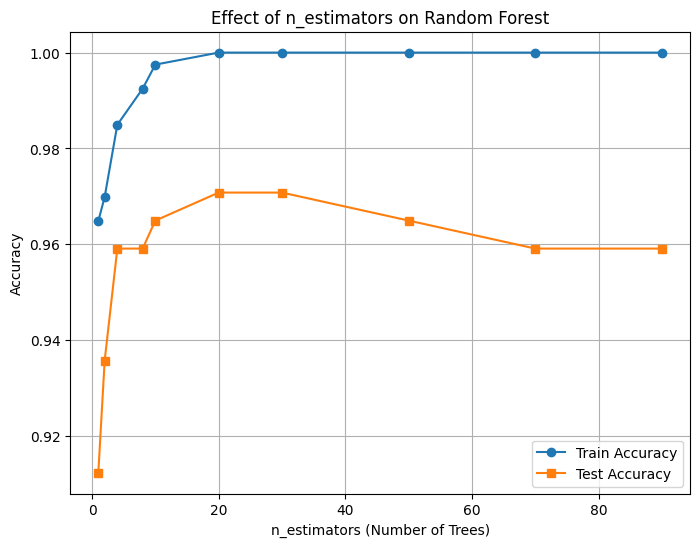

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Test different values of n_estimators
n_estimators_values = [1, 2 ,4, 8, 10, 20, 30, 50, 70, 90]
train_scores = []
test_scores = []

for n in n_estimators_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(n_estimators_values, train_scores, marker='o', label='Train Accuracy')
plt.plot(n_estimators_values, test_scores, marker='s', label='Test Accuracy')
plt.xlabel('n_estimators (Number of Trees)')
plt.ylabel('Accuracy')
plt.title('Effect of n_estimators on Random Forest')
plt.legend()
plt.grid(True)
plt.show()


## Exploring the Effect of the `max_depth` Hyperparameter

The `max_depth` parameter controls the **maximum depth of each tree**:
- **Low `max_depth` values** → Shallow trees → Simpler models, possibly underfitting.
- **High `max_depth` values** → Deeper trees → More complex models, potentially overfitting.

We will now examine how varying `max_depth` affects the model’s performance, while keeping `n_estimators` fixed.


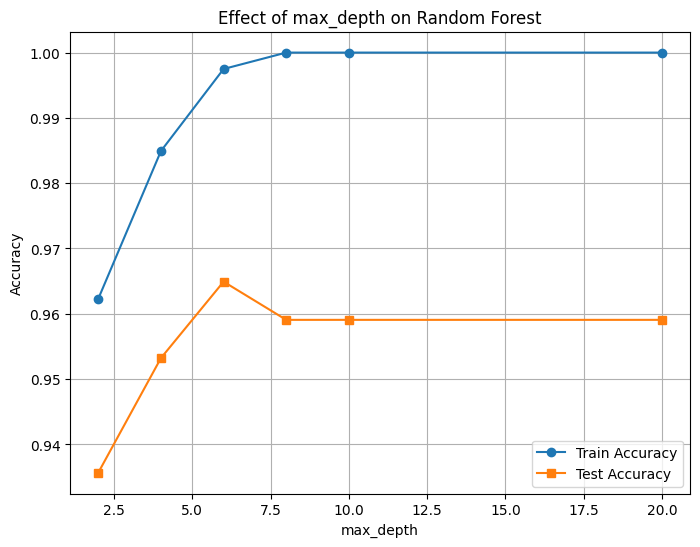

In [3]:
# Test different values of max_depth
max_depth_values = [2, 4, 6, 8, 10, 20]
train_scores = []
test_scores = []

for depth in max_depth_values:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot(max_depth_values, train_scores, marker='o', label='Train Accuracy')
plt.plot(max_depth_values, test_scores, marker='s', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Random Forest')
plt.legend()
plt.grid(True)
plt.show()


## Exploring the Effect of the `min_samples_split` Hyperparameter

The `min_samples_split` parameter controls the **minimum number of samples required to split an internal node**:
- **Low `min_samples_split` values** → More splits → Complex trees, potentially overfitting.
- **High `min_samples_split` values** → Fewer splits → Simpler trees, possibly underfitting.

We will now compare different `min_samples_split` values to observe their impact on performance.


min_samples_split: 2 → Train Accuracy: 0.997, Test Accuracy: 0.965
min_samples_split: 5 → Train Accuracy: 0.995, Test Accuracy: 0.959
min_samples_split: 10 → Train Accuracy: 0.980, Test Accuracy: 0.947
min_samples_split: 20 → Train Accuracy: 0.972, Test Accuracy: 0.947
min_samples_split: 50 → Train Accuracy: 0.972, Test Accuracy: 0.942


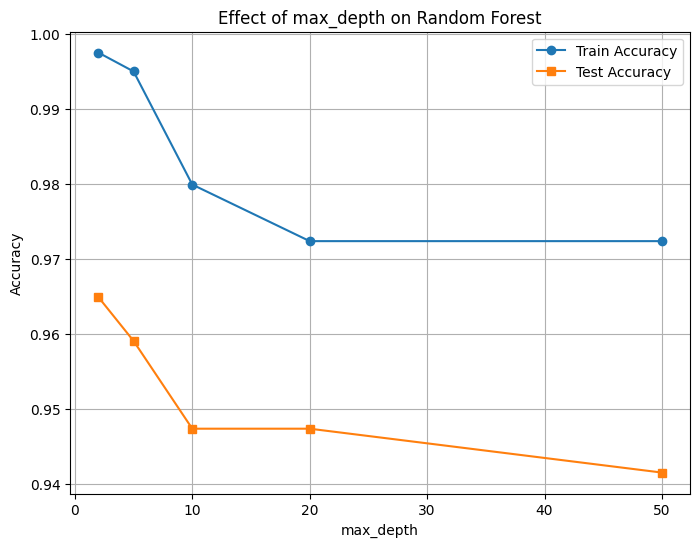

In [4]:
# Test different values of min_samples_split
min_samples_split_values = [2, 5, 10, 20, 50]
train_scores = []
test_scores = []

for min_split in min_samples_split_values:
    model = RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_split=min_split, random_state=42)
    model.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    train_scores.append(train_acc)
    test_scores.append(test_acc)

# Show numeric results
for m, tr, te in zip(min_samples_split_values, train_scores, test_scores):
    print(f"min_samples_split: {m} → Train Accuracy: {tr:.3f}, Test Accuracy: {te:.3f}")

# Plot the results
import numpy as np

x = np.arange(len(min_samples_split_values))
width = 0.35

# plt.figure(figsize=(8, 6))
# plt.bar(x - width/2, train_scores, width, label='Train Accuracy')
# plt.bar(x + width/2, test_scores, width, label='Test Accuracy')
# plt.xticks(x, min_samples_split_values)
# plt.xlabel('min_samples_split')
# plt.ylabel('Accuracy')
# plt.title('Effect of min_samples_split on Random Forest')
# plt.legend()
# plt.grid(True, axis='y')
# plt.show()

# Plot the results
plt.figure(figsize=(8, 6))
plt.plot( min_samples_split_values, train_scores, marker='o', label='Train Accuracy')
plt.plot( min_samples_split_values, test_scores, marker='s', label='Test Accuracy')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Random Forest')
plt.legend()
plt.grid(True)
plt.show()


## Changing the Classification Threshold

Most classifiers output probabilities between 0 and 1.
By default, the threshold for classification is 0.5. This means:

- If predicted probability ≥ 0.5 → classify as **positive**
- Else → classify as **negative**

### Changing the Threshold:
- **Lower threshold** → more positives predicted → higher **recall**, more **false positives**
- **Higher threshold** → fewer positives predicted → higher **precision**, more **false negatives**

Choosing the right threshold depends on your application's goals.

We'll now visualize how the confusion matrix changes for **two different thresholds**.

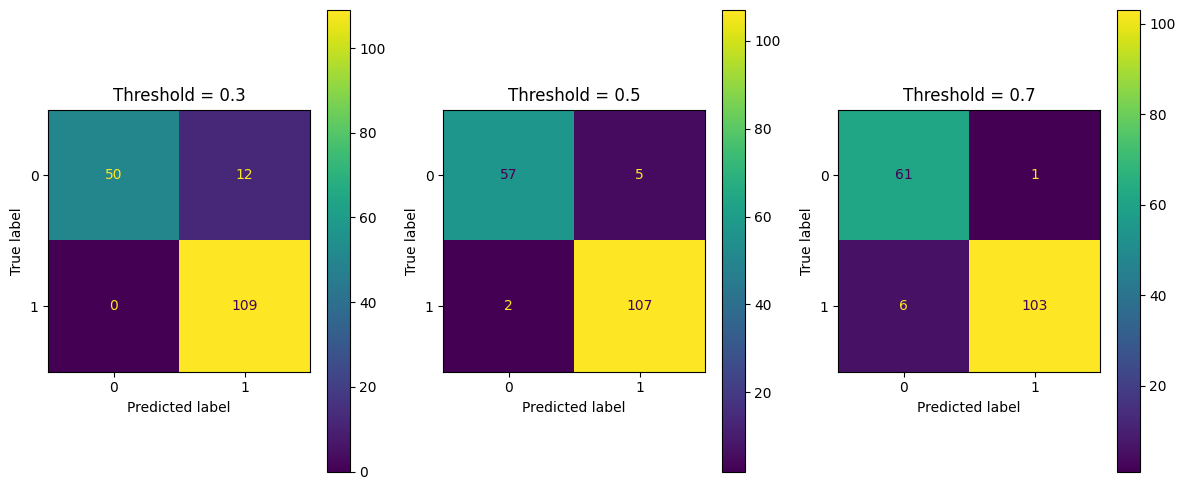

In [5]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

thresholds = [0.3, 0.5, 0.7]         # List of two thresholds to compare


# Train Random Forest with probability estimates
model = RandomForestClassifier(n_estimators=100, max_depth=6, min_samples_split=5, random_state=42)
model.fit(X_train, y_train)

# Predict probabilities
y_proba = model.predict_proba(X_test)[:, 1]  # Probability of class 1

# Plot side-by-side confusion matrices
fig, axs = plt.subplots(1, 3, figsize=(12, 5))
for i, thresh in enumerate(thresholds):
    y_pred = (y_proba >= thresh).astype(int)
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axs[i])
    axs[i].set_title(f"Threshold = {thresh}")
plt.tight_layout()
plt.show()
